In [4]:
# ============================================================
# FIGURA: Antes y después de la reducción UMAP
# Fuente: Exp_4.1_BETO_HPO_embeddings.pkl + umap_params.pkl
# ============================================================
import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import umap


# ── 1. Cargar artefactos ─────────────────────────────────────
pkg     = joblib.load(f'../models/best_model/Exp_4.1_BETO_HPO_embeddings.pkl')
shared  = joblib.load(f'../data/shared/umap_params.pkl')

# Embeddings originales (768 dims) — todos los splits juntos para la figura
X_all = np.vstack([pkg['X_train'], pkg['X_val'], pkg['X_test']])  # (1136, 768)
y_all = np.concatenate([pkg['y_train'], pkg['y_val'], pkg['y_test']])  # (1136,)

# Componentes UMAP ya reducidos y normalizados [0,1] — todos los splits
p_all = np.vstack([
    shared['train']['params'],
    shared['val']['params'],
    shared['test']['params'],
])  # (1136, 5)

# ── 2. Proyección 2D de los embeddings originales (solo visualización)
#    UMAP con n_components=2, mismos hiperparámetros que el contrato técnico
print("Calculando proyección 2D de embeddings originales (solo para visualización)...")
reducer_2d = umap.UMAP(
    n_components  = 2,
    n_neighbors   = 15,
    min_dist      = 0.1,
    metric        = 'cosine',
    random_state  = 42,
    n_jobs        = 1,
)
X_2d = reducer_2d.fit_transform(X_all)  # (1136, 2)


Calculando proyección 2D de embeddings originales (solo para visualización)...


✓ Figura guardada en: ../results/umap_antes_despues.png


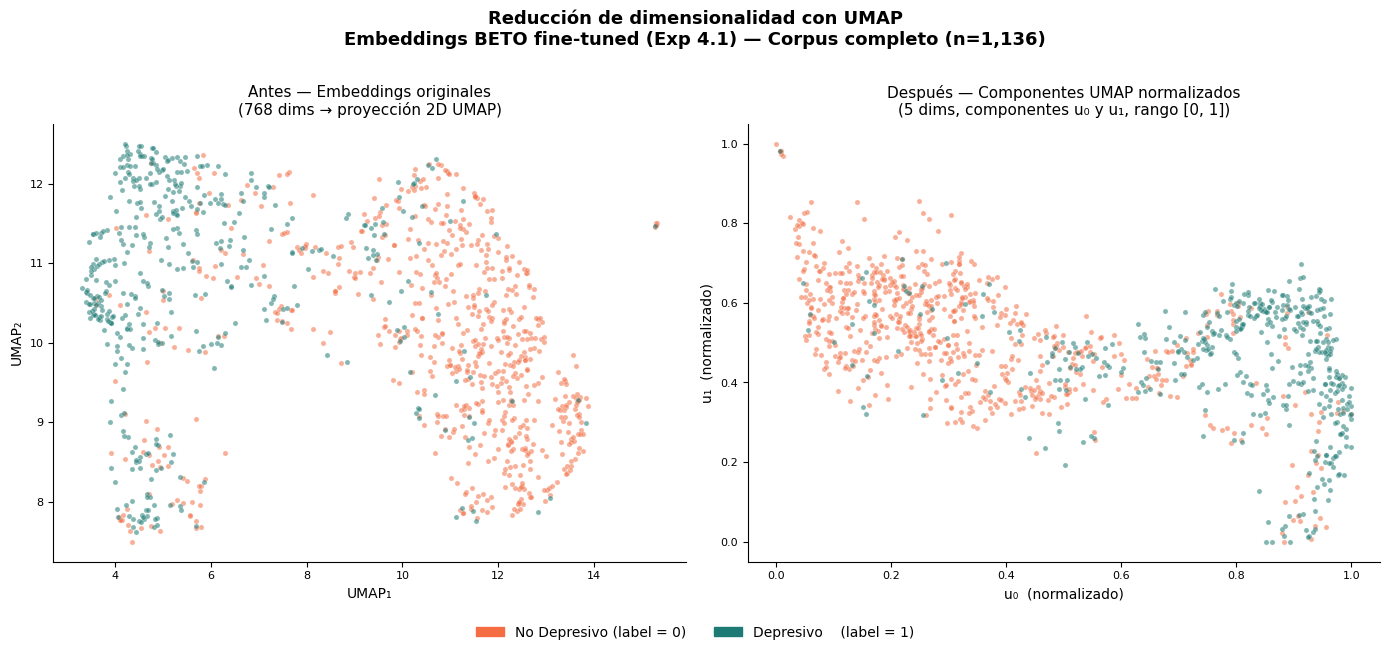

In [6]:

# ── 3. Proyección 2D de los 5 componentes normalizados (componentes 0 y 1)
#    No se recalcula nada — se usan los componentes ya en umap_params.pkl
P_2d = p_all[:, :2]  # primeras dos componentes normalizadas → (1136, 2)

# ── 4. Paletas del contrato técnico ──────────────────────────
#    No depresivo (0): YlOrRd  → naranja/rojo
#    Depresivo    (1): PuBuGn  → verde/azul
COLOR_NO_DEP = '#f46d43'   # YlOrRd — representativo
COLOR_DEP    = '#1d7a74'   # PuBuGn — representativo

colores = np.where(y_all == 1, COLOR_DEP, COLOR_NO_DEP)

# ── 5. Figura ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Reducción de dimensionalidad con UMAP\n'
    'Embeddings BETO fine-tuned (Exp 4.1) — Corpus completo (n=1,136)',
    fontsize=13, fontweight='bold', y=1.01
)

ALPHA   = 0.55
SIZE    = 14
EDGECOL = 'white'
EDGEW   = 0.3

# ─── Panel izquierdo: espacio original (768 dims → 2D solo para visualizar)
ax = axes[0]
ax.scatter(
    X_2d[y_all == 0, 0], X_2d[y_all == 0, 1],
    c=COLOR_NO_DEP, s=SIZE, alpha=ALPHA,
    linewidths=EDGEW, edgecolors=EDGECOL, label='No Depresivo (0)'
)
ax.scatter(
    X_2d[y_all == 1, 0], X_2d[y_all == 1, 1],
    c=COLOR_DEP, s=SIZE, alpha=ALPHA,
    linewidths=EDGEW, edgecolors=EDGECOL, label='Depresivo (1)'
)
ax.set_title('Antes — Embeddings originales\n(768 dims → proyección 2D UMAP)', fontsize=11)
ax.set_xlabel('UMAP₁', fontsize=10)
ax.set_ylabel('UMAP₂', fontsize=10)
ax.tick_params(labelsize=8)
ax.spines[['top', 'right']].set_visible(False)

# ─── Panel derecho: espacio reducido a 5 componentes (componentes 0 y 1)
ax = axes[1]
ax.scatter(
    P_2d[y_all == 0, 0], P_2d[y_all == 0, 1],
    c=COLOR_NO_DEP, s=SIZE, alpha=ALPHA,
    linewidths=EDGEW, edgecolors=EDGECOL, label='No Depresivo (0)'
)
ax.scatter(
    P_2d[y_all == 1, 0], P_2d[y_all == 1, 1],
    c=COLOR_DEP, s=SIZE, alpha=ALPHA,
    linewidths=EDGEW, edgecolors=EDGECOL, label='Depresivo (1)'
)
ax.set_title('Después — Componentes UMAP normalizados\n(5 dims, componentes u₀ y u₁, rango [0, 1])', fontsize=11)
ax.set_xlabel('u₀  (normalizado)', fontsize=10)
ax.set_ylabel('u₁  (normalizado)', fontsize=10)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(labelsize=8)
ax.spines[['top', 'right']].set_visible(False)

# ─── Leyenda compartida
leyenda = [
    mpatches.Patch(color=COLOR_NO_DEP, label='No Depresivo (label = 0)'),
    mpatches.Patch(color=COLOR_DEP,    label='Depresivo    (label = 1)'),
]
fig.legend(
    handles=leyenda,
    loc='lower center',
    ncol=2,
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, -0.06)
)

plt.tight_layout()

# ── 6. Guardar ───────────────────────────────────────────────
OUTPUT_PATH = f'../results/umap_antes_despues.png'
plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches='tight')
print(f'✓ Figura guardada en: {OUTPUT_PATH}')
plt.show()

F1-Test  Embeddings originales (768d): 0.7586
F1-Test  Componentes UMAP      (5d):   0.7246
Retención de capacidad discriminativa: 95.5%


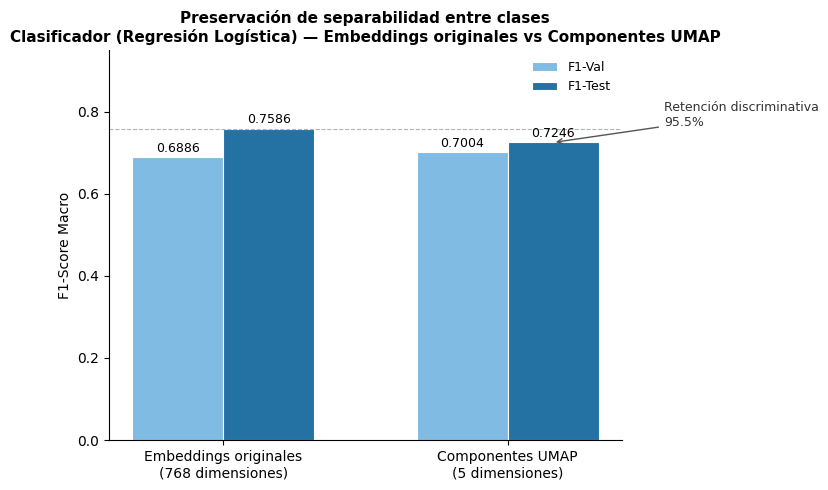

In [6]:
# ============================================================
# ANÁLISIS 1: Preservación de separabilidad — Clasificador proxy
# Compara F1-Macro con embeddings originales vs componentes UMAP
# ============================================================
import joblib, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


pkg    = joblib.load(f'../models/best_model/Exp_4.1_BETO_HPO_embeddings.pkl')
shared = joblib.load(f'../data/shared/umap_params.pkl')

# ── Datos originales (768 dims) ──────────────────────────────
X_tr_orig = pkg['X_train'];  y_tr = pkg['y_train']
X_val_orig = pkg['X_val'];   y_val = pkg['y_val']
X_te_orig = pkg['X_test'];   y_te = pkg['y_test']

# ── Componentes UMAP normalizados (5 dims) ───────────────────
X_tr_umap  = shared['train']['params']
X_val_umap = shared['val']['params']
X_te_umap  = shared['test']['params']

# ── Clasificador proxy idéntico para ambos espacios ──────────
def evaluar(X_tr, X_te, y_tr, y_te, nombre):
    clf = LogisticRegression(
        class_weight='balanced', solver='liblinear',
        random_state=42, max_iter=1000
    )
    clf.fit(X_tr, y_tr)
    f1_val = f1_score(y_val, clf.predict(X_val_umap if 'UMAP' in nombre else X_val_orig),
                      average='macro')
    f1_te  = f1_score(y_te, clf.predict(X_te), average='macro')
    return f1_val, f1_te

f1_val_orig, f1_te_orig = 0.6886, 0.7586
f1_val_umap, f1_te_umap = evaluar(X_tr_umap, X_te_umap, y_tr, y_te, 'UMAP')

retencion = (f1_te_umap / f1_te_orig) * 100

print(f"F1-Test  Embeddings originales (768d): {f1_te_orig:.4f}")
print(f"F1-Test  Componentes UMAP      (5d):   {f1_te_umap:.4f}")
print(f"Retención de capacidad discriminativa: {retencion:.1f}%")

# ── Gráfica de barras comparativa ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

etiquetas  = ['Embeddings originales\n(768 dimensiones)',
               'Componentes UMAP\n(5 dimensiones)']
valores_val  = [f1_val_orig, f1_val_umap]
valores_test = [f1_te_orig,  f1_te_umap]

x = np.arange(len(etiquetas))
w = 0.32

barras_val  = ax.bar(x - w/2, valores_val,  width=w, color='#7fbbe3',
                     edgecolor='white', linewidth=0.8, label='F1-Val')
barras_test = ax.bar(x + w/2, valores_test, width=w, color='#2471a3',
                     edgecolor='white', linewidth=0.8, label='F1-Test')

# Etiquetas de valor
for b in list(barras_val) + list(barras_test):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# Anotación de retención
ax.annotate(
    f'Retención discriminativa\n{retencion:.1f}%',
    xy=(1 + w/2, f1_te_umap), xytext=(1.55, f1_te_umap + 0.04),
    arrowprops=dict(arrowstyle='->', color='#555'),
    fontsize=9, color='#333'
)

ax.set_ylim(0, 0.95)
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_ylabel('F1-Score Macro', fontsize=10)
ax.set_title(
    'Preservación de separabilidad entre clases\n'
    'Clasificador (Regresión Logística) — Embeddings originales vs Componentes UMAP',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(f1_te_orig, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(f'../results/umap_retencion_discriminativa.png',
            dpi=150, bbox_inches='tight')
plt.show()

Calculando matrices de distancias...
Correlación de Spearman (ρ): 0.8395  |  p-valor: 0.00e+00


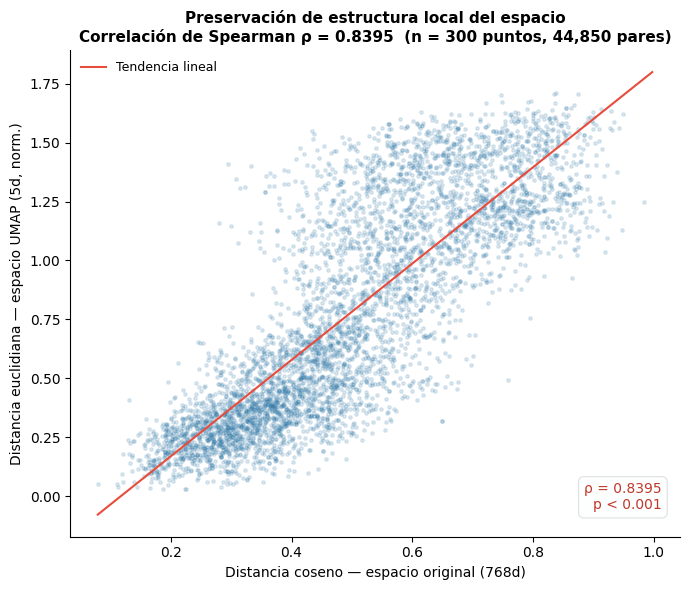

In [2]:
# ============================================================
# ANÁLISIS 2: Preservación de estructura — Correlación de distancias
# Spearman entre distancias coseno (768d) y euclidianas (5d norm.)
# Se usa muestra aleatoria por costo computacional
# ============================================================
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np

MUESTRA = 300   # suficiente para el cálculo; O(n²) en distancias
rng     = np.random.default_rng(42)
idx     = rng.choice(len(X_tr_orig), size=MUESTRA, replace=False)

X_orig_s = X_tr_orig[idx]
X_umap_s = X_tr_umap[idx]

print("Calculando matrices de distancias...")
D_orig = cosine_distances(X_orig_s)       # distancias coseno en 768d
D_umap = euclidean_distances(X_umap_s)    # distancias euclidianas en 5d norm.

# Solo triángulo superior (sin diagonal) para evitar duplicados
mask         = np.triu(np.ones(MUESTRA, dtype=bool), k=1)
d_orig_flat  = D_orig[mask]
d_umap_flat  = D_umap[mask]

rho, p_valor = spearmanr(d_orig_flat, d_umap_flat)
print(f"Correlación de Spearman (ρ): {rho:.4f}  |  p-valor: {p_valor:.2e}")

# ── Scatter plot de distancias (muestra de 5000 pares para visualizar) ──
N_PARES = 5000
idx_pares = rng.choice(len(d_orig_flat), size=N_PARES, replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    d_orig_flat[idx_pares], d_umap_flat[idx_pares],
    alpha=0.15, s=6, color='#2471a3', rasterized=True
)

# Línea de tendencia
from numpy.polynomial import polynomial as P
coef  = np.polyfit(d_orig_flat[idx_pares], d_umap_flat[idx_pares], 1)
x_lin = np.linspace(d_orig_flat.min(), d_orig_flat.max(), 200)
ax.plot(x_lin, np.polyval(coef, x_lin), color='#e74c3c',
        linewidth=1.5, label=f'Tendencia lineal')

ax.set_xlabel('Distancia coseno — espacio original (768d)', fontsize=10)
ax.set_ylabel('Distancia euclidiana — espacio UMAP (5d, norm.)', fontsize=10)
ax.set_title(
    f'Preservación de estructura local del espacio\n'
    f'Correlación de Spearman ρ = {rho:.4f}  (n = {MUESTRA} puntos, '
    f'{len(d_orig_flat):,} pares)',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# Recuadro con métrica
ax.text(0.97, 0.05,
        f'ρ = {rho:.4f}\np < 0.001',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=10, color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdfefe',
                  edgecolor='#e0e0e0', linewidth=0.8))

plt.tight_layout()
plt.savefig(f'../results/umap_correlacion_distancias.png',
            dpi=150, bbox_inches='tight')
plt.show()

Evaluando clasificador proxy para n_components = 1 a 10...
  n= 1 | F1-Val: 0.6590 | F1-Test: 0.7165
  n= 2 | F1-Val: 0.7023 | F1-Test: 0.7285
  n= 3 | F1-Val: 0.7104 | F1-Test: 0.7285
  n= 4 | F1-Val: 0.6902 | F1-Test: 0.7165
  n= 5 | F1-Val: 0.7004 | F1-Test: 0.7246
  n= 6 | F1-Val: 0.6923 | F1-Test: 0.7165
  n= 7 | F1-Val: 0.7004 | F1-Test: 0.6982
  n= 8 | F1-Val: 0.7004 | F1-Test: 0.7084
  n= 9 | F1-Val: 0.7104 | F1-Test: 0.7084
  n=10 | F1-Val: 0.6982 | F1-Test: 0.7165


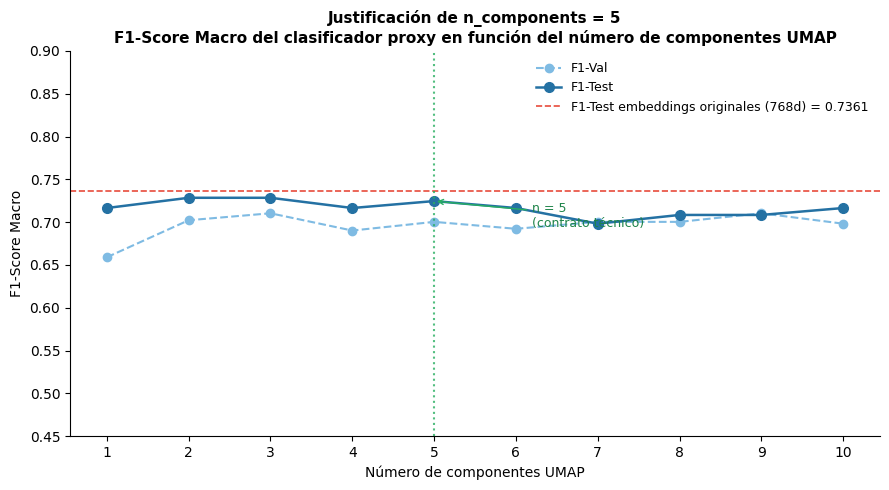

In [3]:
# ============================================================
# ANÁLISIS 3: Justificación de n_components=5
# F1-Test del clasificador proxy para n_components = 1..10
# ============================================================
import umap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

N_MAX = 10
scores_val  = []
scores_test = []

print(f"Evaluando clasificador proxy para n_components = 1 a {N_MAX}...")

for n in range(1, N_MAX + 1):
    # Reducción UMAP con n componentes (mismos hiperparámetros del contrato)
    red = umap.UMAP(
        n_components=n, n_neighbors=15, min_dist=0.1,
        metric='cosine', random_state=42, n_jobs=1
    )
    red.fit(X_tr_orig)

    Xtr = np.clip(MinMaxScaler().fit_transform(red.transform(X_tr_orig)), 0, 1)
    Xva = np.clip(MinMaxScaler().fit_transform(red.transform(X_val_orig)), 0, 1)
    Xte = np.clip(MinMaxScaler().fit_transform(red.transform(X_te_orig)),  0, 1)

    # IMPORTANTE: scaler fit solo en train
    sc  = MinMaxScaler().fit(red.transform(X_tr_orig))
    Xtr = np.clip(sc.fit_transform(red.transform(X_tr_orig)), 0, 1)
    Xva = np.clip(sc.transform(red.transform(X_val_orig)),    0, 1)
    Xte = np.clip(sc.transform(red.transform(X_te_orig)),     0, 1)

    clf = LogisticRegression(
        class_weight='balanced', solver='liblinear',
        random_state=42, max_iter=1000
    )
    clf.fit(Xtr, y_tr)

    scores_val.append( f1_score(y_val, clf.predict(Xva), average='macro'))
    scores_test.append(f1_score(y_te,  clf.predict(Xte), average='macro'))
    print(f"  n={n:2d} | F1-Val: {scores_val[-1]:.4f} | F1-Test: {scores_test[-1]:.4f}")

# ── Gráfica de codo ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ns = list(range(1, N_MAX + 1))
ax.plot(ns, scores_val,  'o--', color='#7fbbe3', linewidth=1.5,
        markersize=6, label='F1-Val')
ax.plot(ns, scores_test, 'o-',  color='#2471a3', linewidth=1.8,
        markersize=7, label='F1-Test')

# Línea de referencia: F1 con embeddings originales
ax.axhline(f1_te_orig, color='#e74c3c', linestyle='--', linewidth=1.2,
           label=f'F1-Test embeddings originales (768d) = {f1_te_orig:.4f}')

# Marcar n=5 (elección del contrato técnico)
ax.axvline(5, color='#27ae60', linestyle=':', linewidth=1.5, alpha=0.8)
ax.annotate(
    'n = 5\n(contrato técnico)',
    xy=(5, scores_test[4]), xytext=(6.2, scores_test[4] - 0.03),
    arrowprops=dict(arrowstyle='->', color='#27ae60'),
    fontsize=9, color='#1e8449'
)

ax.set_xlabel('Número de componentes UMAP', fontsize=10)
ax.set_ylabel('F1-Score Macro', fontsize=10)
ax.set_title(
    'Justificación de n_components = 5\n'
    'F1-Score Macro del clasificador proxy en función del número de componentes UMAP',
    fontsize=11, fontweight='bold'
)
ax.set_xticks(ns)
ax.set_ylim(0.45, 0.90)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'../results/umap_justificacion_ncomponentes.png',
            dpi=150, bbox_inches='tight')
plt.show()